# Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset/avaliacoes_Docentes_Turmas.csv", sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126294 entries, 0 to 126293
Data columns (total 28 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  126294 non-null  object 
 1   sexo                                  126294 non-null  object 
 2   formacao                              126294 non-null  object 
 3   vinculo                               126294 non-null  object 
 4   categoria                             126294 non-null  object 
 5   classe_funcional                      126294 non-null  object 
 6   lotacao                               126294 non-null  object 
 7   id_turma                              126294 non-null  int64  
 8   ano                                   126294 non-null  int64  
 9   periodo                               126294 non-null  int64  
 10  qtd_discentes                         126294 non-null  int64  
 11  

# Tratamento

## Formação do docente
- Agrupamos Doutorado e Pós-doutorado em DOUTOR
- Agrupamos desconhecida e graduação em OUTROS
- Mestrado -> MESTRE
- Especialização -> ESPECIALISTA

<Axes: xlabel='formacao'>

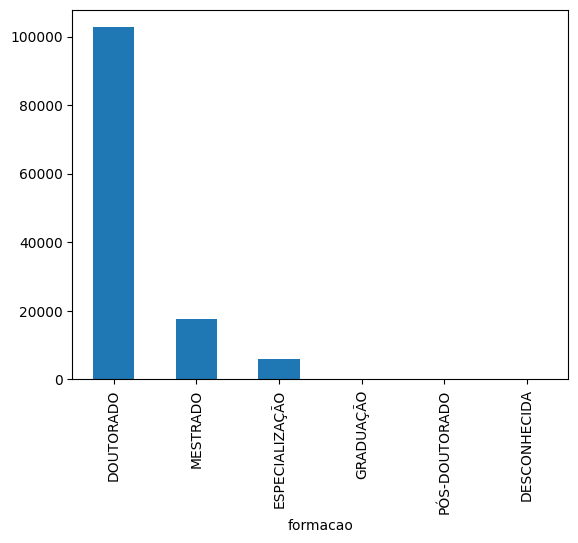

In [3]:
df["formacao"].value_counts().plot(kind="bar")

In [4]:
df["formacao"] = df["formacao"].replace(
    {"ESPECIALIZAÇÃO": "ESPECIALISTA", "MESTRADO": "MESTRE", "DOUTORADO": "DOUTOR", "GRADUAÇÃO":"OUTROS", "PÓS-DOUTORADO":"DOUTOR", "DESCONHECIDA":"OUTROS"}
)
df.formacao.value_counts()

formacao
DOUTOR          102700
MESTRE           17643
ESPECIALISTA      5877
OUTROS              74
Name: count, dtype: int64

## Quantidade de aprovados/Reprovados

- *Total de aprovados* é igual a `aprovados + aprovados por nota`
- *Porcentagem de aprovados* é o `total de aprovados/ número de discentes`
- *Porcentagem de reprovados* é igual a `1 - porcentagem de aprovados`

- Por quê proporção maxima é 1.030303? Por quê tem **uma** turma com 33 discentes e 34 aprovados :)

In [5]:
df_proporcao = df.copy()

df_proporcao["proporcao_aprovados"] = (
    df_proporcao["qtd_aprovado"] + df_proporcao["qtd_aprovado_por_nota"]
) / df_proporcao["qtd_discentes"]
df_proporcao["proporcao_reprovados"] = 1 - df_proporcao["proporcao_aprovados"]

df_proporcao[["proporcao_aprovados", "proporcao_reprovados"]].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
proporcao_aprovados,125793.0,0.907697,0.154262,0.000000,0.875,1.0,1.000,1.030303
proporcao_reprovados,125793.0,0.092303,0.154262,-0.030303,0.000,0.0,0.125,1.000000


## Definição de features finais

- Quantidade de discentes
- Proporção de aprovados
- Média final geral
- Média da postura profissional
- Desvio padrão da postura profissional
- Média da atuação profissional
- Desvio padrão da atuação profissional

É possível adicionar também:
- Sexo do docente
- Nível do docente na instituição (adjunto, associado, etc.)
- Formação do docente

Obs.:
- Removi proporção de reprovados pois tem 100% de correlação com de aprovados
- Removi formação do docente pois estava influenciando muito os clusters


In [6]:
df_proporcao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126294 entries, 0 to 126293
Data columns (total 30 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  126294 non-null  object 
 1   sexo                                  126294 non-null  object 
 2   formacao                              126294 non-null  object 
 3   vinculo                               126294 non-null  object 
 4   categoria                             126294 non-null  object 
 5   classe_funcional                      126294 non-null  object 
 6   lotacao                               126294 non-null  object 
 7   id_turma                              126294 non-null  int64  
 8   ano                                   126294 non-null  int64  
 9   periodo                               126294 non-null  int64  
 10  qtd_discentes                         126294 non-null  int64  
 11  

In [8]:
# Daria pra por sexo do docente tambem, fica a critério aí.
# Pensei em fazer one hot encode da classe do professor
# também, ou transformar em uma série de níveis: 1, 2, 3, 4...


features = [
    "id_turma",
    "qtd_discentes",
    "proporcao_aprovados",
    # "proporcao_reprovados",
    # "formacao_DOUTOR",
    # "formacao_ESPECIALISTA",
    # "formacao_MESTRE",
    "media_final_geral",
    "postura_profissional_media",
    "postura_profissional_DP",
    "atuacao_profissional_media",
    "atuacao_profissional_DP"
]

X_cluster_identificado = df_proporcao[features].dropna()
X_cluster = X_cluster_identificado.drop("id_turma", axis=1)
X_cluster_identificado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125793 entries, 0 to 126293
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id_turma                    125793 non-null  int64  
 1   qtd_discentes               125793 non-null  int64  
 2   proporcao_aprovados         125793 non-null  float64
 3   media_final_geral           125793 non-null  float64
 4   postura_profissional_media  125793 non-null  float64
 5   postura_profissional_DP     125793 non-null  float64
 6   atuacao_profissional_media  125793 non-null  float64
 7   atuacao_profissional_DP     125793 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 8.6 MB


# Clustering

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

## K-Means

### Com k específico

In [10]:
# Um valor só
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
kmeans.fit(X_scaled)

KMeans(n_clusters=4, random_state=42)

### Com um range de k

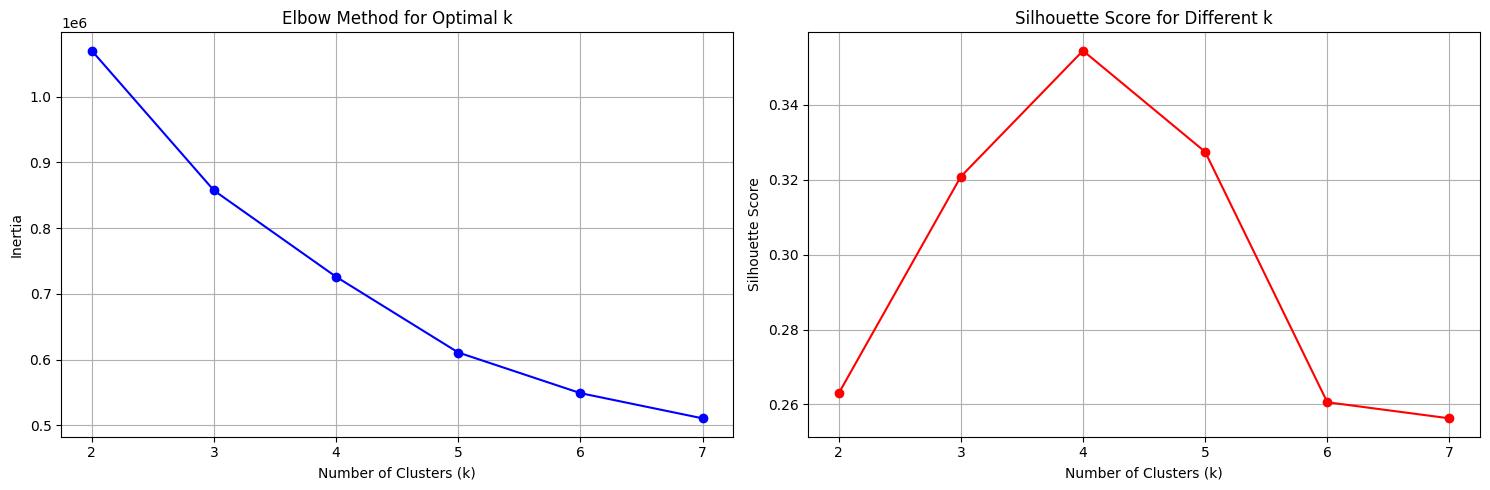

k=2: Silhouette Score = 0.263
k=3: Silhouette Score = 0.321
k=4: Silhouette Score = 0.354
k=5: Silhouette Score = 0.327
k=6: Silhouette Score = 0.261
k=7: Silhouette Score = 0.256


In [ ]:
# Em grupos de 2 a 7
inertias = []
silhouette_scores = []
labels = {}
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    labels[k] = kmeans.labels_
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve and Silhouette Scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Method
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True)

# Silhouette Scores
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Different k')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print silhouette scores
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: Silhouette Score = {score:.3f}")

### Visualizar Clusters

In [11]:
def create_cluster_heatmap(data_with_clusters):
    """Create a heatmap showing cluster characteristics"""
    
    # Calculate cluster profiles
    cluster_stats = []
    
    for cluster_id in sorted(data_with_clusters['cluster'].unique()):
        cluster_data = data_with_clusters[data_with_clusters['cluster'] == cluster_id]
        
        stats = {
            'Cluster': f'Cluster {cluster_id}',
            'Turmas': len(cluster_data),
            'Quantidade de discentes': cluster_data['qtd_discentes'].mean(),
            'Taxa de aprovação': cluster_data['proporcao_aprovados'].mean() * 100,
            #'Taxa de reprovação': cluster_data['proporcao_reprovados'].mean() * 100,
            'Nota final': cluster_data['media_final_geral'].mean(),
            'Postura Profissional': cluster_data['postura_profissional_media'].mean(),
            'Atuação Profissional': cluster_data['atuacao_profissional_media'].mean(),
            # '% Doutores': cluster_data['formacao_DOUTOR'].mean() * 100,
            # '% Mestres': cluster_data['formacao_MESTRE'].mean() * 100,
            # '% Especialistas': cluster_data['formacao_ESPECIALIZAÇÃO'].mean() * 100,
        }
        
        cluster_stats.append(stats)
    
    # Convert to DataFrame
    cluster_df = pd.DataFrame(cluster_stats)
    cluster_df = cluster_df.set_index('Cluster')
    
    return cluster_df

X_cluster_with_labels = X_cluster_identificado.copy()
#X_cluster_with_labels["cluster"] = labels[6]
X_cluster_with_labels["cluster"] = kmeans.labels_

# Generate cluster profiles DataFrame
cluster_profiles_df = create_cluster_heatmap(X_cluster_with_labels)

X_cluster_with_labels.to_csv("turmas_com_clusters.csv", index=False)

detailed_cluster_profiles = X_cluster_with_labels.groupby("cluster").describe().transpose()
detailed_profile_cols = ["Variavel", "Metrica", "Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"]
detailed_cluster_profiles.to_csv("perfil_detalhado_clusters.csv")

# Display with nice formatting
print("CLUSTER ANALYSIS RESULTS")

# Display cluster profiles
cluster_profiles_df.transpose().round(2)

CLUSTER ANALYSIS RESULTS


Cluster,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Turmas,48530.00,13113.00,50678.00,13472.00
Quantidade de discentes,12.94,26.26,26.98,32.84
Taxa de aprovação,97.21,86.88,94.29,58.14
Nota final,8.26,7.72,8.08,6.53
Postura Profissional,9.84,7.86,9.39,9.31
Atuação Profissional,9.74,8.09,9.10,8.71


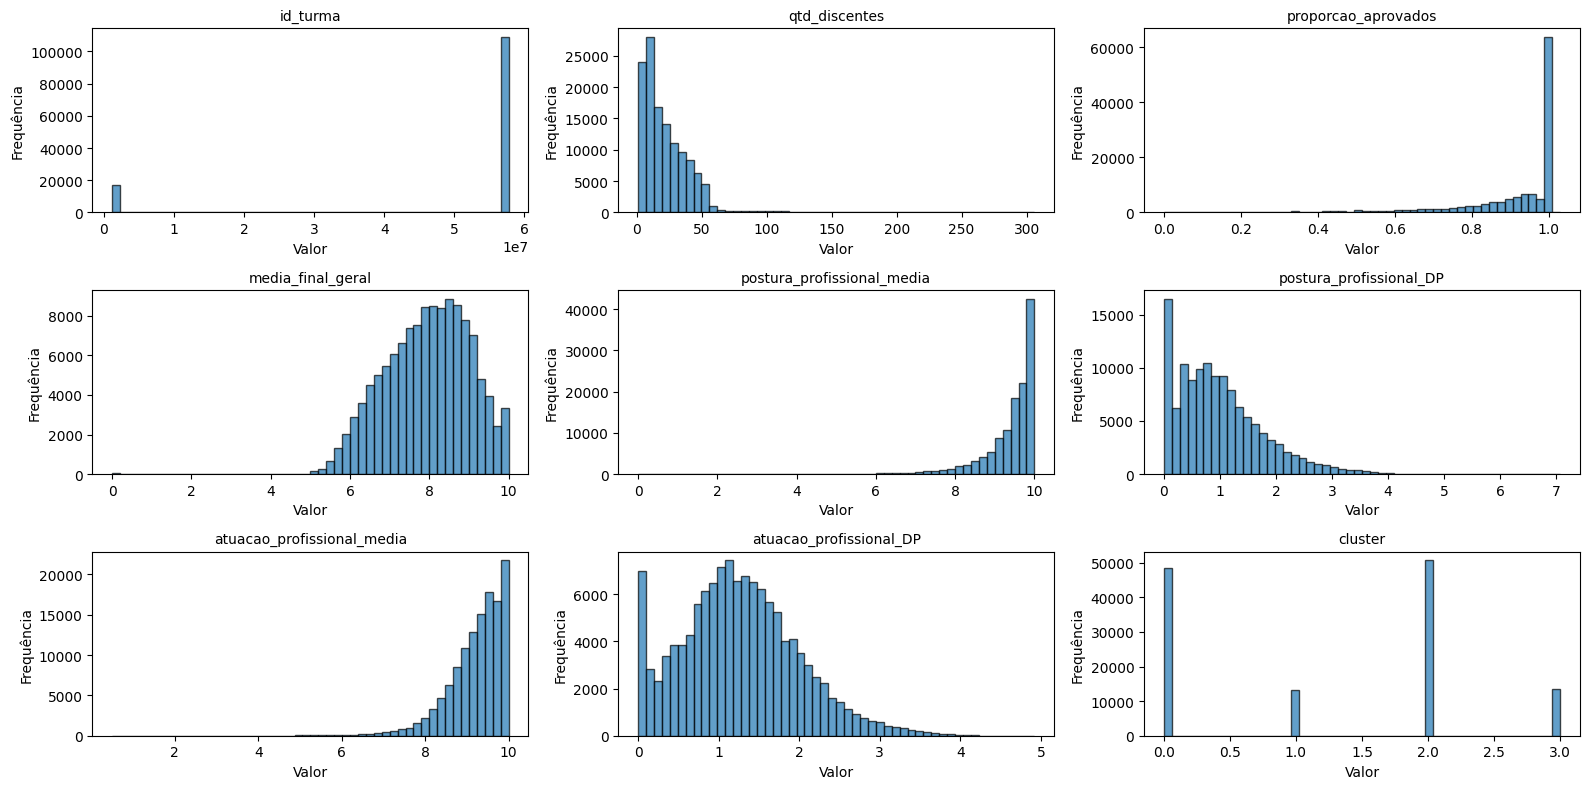

In [14]:
# Colei de Mariana
# Visualização da distribuição das features
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(X_cluster_with_labels.columns):
    axes[idx].hist(X_cluster_with_labels[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=10)
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frequência')

plt.tight_layout()
plt.show()